<a href="https://colab.research.google.com/github/Orliluq/ONE-AI-FOR-TECH-RAG/blob/main/Inteligencia_de_Datos_y_RAG_Avanzado_ONE_AI_FOR_TECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
!pip install -q langchain langchain-google-genai google-generativeai langgraph langchain-huggingface sentence-transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.7 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [ ]:
import os

# Suponiendo que tienes una Clave de API almacenada en una variable de entorno
api_key = os.getenv('GEMINI_API_KEY')

# Usa la Clave de API para acceder a un servicio
print(f"Usando la Clave de API: {api_key}")

In [121]:
# from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatGoogleGenerativeAI(
    # model="gemini-2.5-flash",
    # temperature=0,
    # google_api_key=GEMINI_API_KEY
# )


In [119]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    temperature=0.1
)

hf_llm = HuggingFacePipeline(pipeline=pipe)

# Switch global llm to use local model
llm = hf_llm
print("System switched to local LLM (TinyLlama) to bypass API quota limits.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

System switched to local LLM (TinyLlama) to bypass API quota limits.


In [ ]:
respuesta = llm.invoke("¿Qué es el RAG en Inteligencia Artificial?")

In [ ]:
respuesta.content

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# Asumiendo que GEMINI_API_KEY ya ha sido definida en una celda anterior.
# Creando una instancia del LLM de Google
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", # Cambiado de "gemini-pro" a "gemini-2.5-flash"
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

# Usando el LLM para generar texto
prompt_text = "Explica qué es inteligencia artificial."
response = llm.invoke([HumanMessage(content=prompt_text)]) # Wrap HumanMessage in a list

# Exibiendo la respuesta generada por el LLM
print(response.content)

In [ ]:
PROMPT_TRIAJE = """
Eres un especialista en triaje del Service Desk para politicas internas.
Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
{\n
    "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",\n
    "urgency": "BAJA" | "MEDIANA" | "ALTA",\n
    "missing_fields": ["..."]\n
}\n
Reglas:\n
- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las politicas (Ej.: "¿Puedo reembolsar el internet para mi oficina en casa?").\n
- **PEDIR_INFO**: Mensajes imprecisos o sin información para identificar el tema o el contexto (Ej.: "Necesito ayuda con una politica").\n
- **ABRIR_TICKET**: Solicitudes de excepciones, autorización, aprobación o acceso especial, o cuando el usuario solicita explicitamente abrir un ticket (Ej.: "Quiero una excepción para trabajar remotamente durante 5 dias").\n
Analiza el mensaje y decide la acción más adecuada.
"""

In [ ]:
from typing import Literal, List, Dict

In [ ]:
from pydantic import BaseModel, Field

In [ ]:
class TriajeOut(BaseModel):
    decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"]
    urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
    campos_faltantes: List[str] = Field(default_factory=list)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

In [ ]:
chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
    salida: TriajeOut = chain_de_triaje.invoke(
        [
            SystemMessage(content=PROMPT_TRIAJE),
            HumanMessage(content=mensaje)
        ]
    )
    return salida.model_dump()

In [ ]:
mensajes_de_prueba = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una política para anticipos de vacaciones?",
    "¿Quién fue Napoleón Bonaparte?"
]

In [ ]:
for pregunta in mensajes_de_prueba:
    r = triaje(pregunta)
    print(f"{pregunta} -> {r}")

## Describiendo los documentos de recursos humanos

In [ ]:
!pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf

In [ ]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for n in Path("/content/").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(n))
        docs.extend(loader.load())
        print(f"Archivo cargado: {n.name}")
    except Exception as e:
        print(f"Error cargando archivo: {n.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)

In [ ]:
docs_splits = splitter.split_documents(docs)

In [ ]:
for chunk in docs_splits:
    print(chunk)
    print("-----------------")

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [ ]:
modelo_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

In [ ]:
from langchain_community.vectorstores import FAISS

In [ ]:
vectorstore = FAISS.from_documents(docs_splits, modelo_embeddings)

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.3, "k": 4}
)

In [ ]:
# Suponemos que tenemos una función para buscar documentos
def buscar_documentos(pregunta):
    # Esta función devuelve documentos relevantes
    documentos = {
        "pandas": "Los pandas se alimentan principalmente de bambú."
    }
    return documentos.get(pregunta.lower(), "")

# Función para generar respuesta usando GPT
def generar_respuesta(pregunta):
    # Primero, recuperamos documentos relevantes
    documento = buscar_documentos(pregunta)

    # Luego, usamos el modelo de IA para generar una respuesta
    if documento:
        respuesta = f"Basado en información interna, sabemos que {documento}"
    else:
        respuesta = "Lo siento, no tengo suficiente información para responder a eso."

    return respuesta

# Ejemplo de uso
pregunta = "¿Qué comen los pandas?"
print(generar_respuesta(pregunta))

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
# from langchain.chains.combine_documents import create_stuff_documents_chain # This import is no longer needed and causes a ModuleNotFoundError

In [ ]:
prompt_rag = ChatPromptTemplate(
    [
        ("system",
            """Eres el especialista en RR.HH. de la empresa Carraro Desarrollo de Software.
            Responde siempre utilizando los conocimientos de las bases de datos pasadas a ti.
            Si no hay informacion sobre la pregunta en los datos, responde solo 'No lo se'.
            """
        ),
        ("human", "Contexto: {context}\nPregunta del empleado: {question}") # Changed {input} to {question}
    ]
)

# document_chain = create_stuff_documents_chain(llm, prompt_rag) # This is no longer needed and caused an error

In [ ]:
def busqueda_de_respuestas_RAG(pregunta) -> Dict:
  # The 'retriever' variable in the global scope will now refer to the one
  # associated with the Chroma vector store (defined in cell LsZXp5N89aAB).
  documentos_relacionados = retriever.invoke(pregunta)

  if not documentos_relacionados:
    return {
        "respuesta": "No lo sé",
        "citaciones": [],
        "documentos_encontrados": False
    }

  # Use the 'rag_chain' (defined in cell 3CKgOUx99tVA) which is functional.
  # It handles the context formatting and LLM invocation internally.
  answer = rag_chain.invoke(pregunta)

  if answer.rstrip(".!?") == "No lo sé":
      return {
          "respuesta": "No lo sé",
          "citaciones": [],
          "documentos_encontrados": False
      }

  return {
      "respuesta": answer,
      "citaciones": documentos_relacionados, # Use the separately retrieved documents for citations
      "documentos_encontrados": True
  }

In [ ]:
busqueda_de_respuestas_RAG("¿Puedo obtener un reembolso por el internet de mi home office?")

In [ ]:
mensajes_de_prueba = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una politica para anticipos de vacaciones?",
    "¿Quién fue Napoleon Bonaparte?"
]

In [ ]:
r = busqueda_de_respuestas_RAG("¿Puedo obtener un reembolso por el internet de mi home office?")
print(r)

In [ ]:
print(f"Número de citaciones para la última respuesta: {len(r['citaciones'])}")

In [ ]:
for pregunta in mensajes_de_prueba:
    respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)

    print(f"\nPREGUNTA: {pregunta}")
    print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
    print(f"DOCUMENTOS ENCONTRADOS: {respuesta_RAG['documentos_encontrados']}")

    if respuesta_RAG['documentos_encontrados']:
        for i, citacion in enumerate(respuesta_RAG['citaciones'], start=1):
            print(f"\nCITACION {i}:")
            print(
                f"Camino del documento: "
                f"{citacion.metadata.get('file_path', 'No disponible')}"
            )
            print(
                f"Contenido: "
                f"{citacion.page_content.replace(chr(10), ' ')}"
            )

    print("\n" + "=" * 80)

In [ ]:
import time

# Nos aseguramos de que el rag_chain use el LLM local para evitar errores de cuota
# hf_llm fue definido en la celda fe500b6a
if 'hf_llm' in globals():
    llm = hf_llm

for pregunta in mensajes_de_prueba:
    try:
        print(f"PROCESANDO: {pregunta}")
        respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)

        print(f"PREGUNTA: {pregunta}")
        print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
        print(f"DOCUMENTOS ENCONTRADOS: {respuesta_RAG['documentos_encontrados']}")

        if respuesta_RAG['documentos_encontrados']:
            for i, citacion in enumerate(respuesta_RAG['citaciones']):
                print(f"  CITACION {i + 1}:")
                # Usamos .get() para evitar errores si la clave no existe
                source = citacion.metadata.get('file_path', citacion.metadata.get('source', 'Desconocido'))
                print(f"    Origen: {source}")
                print(f"    Contenido: {citacion.page_content[:200].replace('\n', ' ')}...")

        print("-" * 30)
        # Pequeña pausa para no saturar la salida si el modelo es muy rápido
        time.sleep(0.5)

    except Exception as e:
        print(f"Error al procesar la pregunta '{pregunta}': {e}")

In [65]:
!apt-get install graphviz -y
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


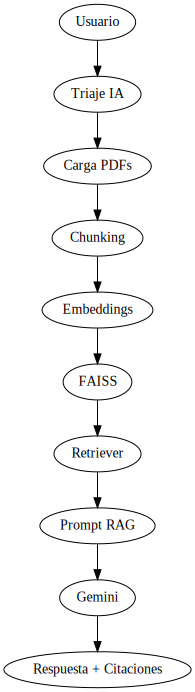

In [66]:
from graphviz import Digraph

g = Digraph("RAG_Flow", format="png")

g.attr(rankdir="TB")

g.node("A", "Usuario")
g.node("B", "Triaje IA")
g.node("C", "Carga PDFs")
g.node("D", "Chunking")
g.node("E", "Embeddings")
g.node("F", "FAISS")
g.node("G", "Retriever")
g.node("H", "Prompt RAG")
g.node("I", "Gemini")
g.node("J", "Respuesta + Citaciones")

g.edge("A", "B")
g.edge("B", "C")
g.edge("C", "D")
g.edge("D", "E")
g.edge("E", "F")
g.edge("F", "G")
g.edge("G", "H")
g.edge("H", "I")
g.edge("I", "J")

g.render("diagrama_rag", view=False)

g

# OTRO PLANTEAMIENTO

## Instalar dependencias

In [ ]:
# !pip install -q \
# langchain \
# langchain-openai \
# langchain-community \
# langchain-core \
# chromadb \
# pypdf \
# tiktoken \
# langchain-text-splitters # Commented out to prevent dependency conflicts

 ## Configurar API Key

In [ ]:
from google.colab import userdata
import os

os.environ["OPEN_AI_API_KEY"] = userdata.get("OPEN_AI_API_KEY")

## Subir PDFs

In [ ]:
from google.colab import files

uploaded = files.upload()

## Cargar documentos

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

documents = []

for file_name in uploaded.keys():
    loader = PyPDFLoader(file_name)
    docs = loader.load()

    documents.extend(docs)

print(f"Documentos cargados: {len(documents)}")

## Chunking

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print(f"Chunks creados: {len(chunks)}")

## Crear embeddings

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

documents = []

for file_name in uploaded.keys():
    loader = PyPDFLoader(file_name)
    docs = loader.load()

    documents.extend(docs)

print(f"Documentos cargados: {len(documents)}")

In [ ]:
from langchain_openai import OpenAIEmbeddings
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

try:
    # Attempt to retrieve the API key directly from Colab secrets
    # The context indicates the user might have set 'OPEN_AI_API_KEY' or 'openai_key'.
    # This code specifically looks for 'OPEN_AI_API_KEY'.
    openai_api_key = userdata.get("OPEN_AI_API_KEY")
except SecretNotFoundError:
    raise ValueError(
        "OpenAI API key not found. Please ensure you have set a Colab secret "
        "named 'OPEN_AI_API_KEY' (or 'openai_key' if that's what you intended to use, "
        "and adjust the code accordingly). Alternatively, set the 'OPENAI_API_KEY' "
        "environment variable (without the underscore in 'OPENAI_API_KEY' for LangChain)."
    )

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=openai_api_key  # Pass the key directly to the constructor
)

### Usar Embeddings de HuggingFace (gratuitos y locales)

In [ ]:
# Instalar las librerías necesarias para HuggingFace Embeddings y la versión recomendada por LangChain
# !pip install -q --force-reinstall langchain-huggingface sentence-transformers transformers # Commented out to prevent dependency conflicts

### Instalar librerías adicionales para ejecutar modelos locales (HuggingFace LLM)

In [ ]:
# `accelerate` y `bitsandbytes` son útiles para ejecutar modelos más grandes de forma eficiente.
# `torch` debería estar instalado por otras dependencias, pero asegúrate de que sea una versión compatible.
# !pip install -q accelerate bitsandbytes # Commented out to prevent dependency conflicts

In [ ]:
# Importar HuggingFaceEmbeddings de la nueva ubicación recomendada
from langchain_huggingface import HuggingFaceEmbeddings

# Inicializar HuggingFaceEmbeddings con un modelo pre-entrenado. Puedes elegir otros modelos si lo deseas.
# 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2' es un buen modelo multilingüe.
# Para modelos en español, considera 'hiiamsid/sentence_similarity_spanish_es'
# O 'distilbert-base-nli-stsb-mean-tokens' para inglés (requiere descargar el modelo)

hf_embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Asignar la instancia de HuggingFaceEmbeddings a la variable 'embeddings'
# para que el siguiente paso de Chroma.from_documents la use.
embeddings = hf_embeddings

print("Embeddings de HuggingFace inicializados correctamente.")

In [ ]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_db"
)

print("Base vectorial creada")

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

In [ ]:
query = "¿Cuál es el objetivo principal del documento?"

results = retriever.invoke(query)

for i, doc in enumerate(results):
    print(f"\n--- Chunk {i+1} ---\n")
    print(doc.page_content[:500])

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
Eres un asistente especializado en responder preguntas
usando exclusivamente el contexto proporcionado.

Reglas:

1. Responde únicamente con información presente en el contexto.
2. No inventes datos.
3. Si la respuesta no está en el contexto, responde:

"No encontré información suficiente en los documentos para responder esa pregunta."

Contexto:

{context}

Pregunta:

{question}

Respuesta:
""")

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=openai_api_key # Pasa la clave directamente al constructor
)

### Configurar un LLM de Hugging Face

In [125]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline
import torch

# Define el nombre del modelo de Hugging Face que quieres usar
# TinyLlama/TinyLlama-1.1B-Chat-v1.0 es un modelo pequeño adecuado para pruebas en Colab
# Si tienes GPU y más RAM, puedes probar modelos más grandes como 'google/gemma-2b-it'
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# Cargar el tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Cargar el modelo. Usa torch_dtype=torch.bfloat16 para mayor eficiencia si tu GPU lo soporta.
# Si tienes problemas de memoria, puedes intentar cargar con quantization_config (e.g., bitsandbytes)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")

# Crear un pipeline de texto con el modelo y el tokenizer
pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=100,
    temperature=0.1,
    do_sample=False
    # max_new_tokens=512, # Limita la longitud de la respuesta generada
    # temperature=0.1,    # Ajusta para controlar la creatividad de la respuesta
)

# Inicializar el LLM de HuggingFace para LangChain
hf_llm = HuggingFacePipeline(pipeline=pipeline)

# Sobrescribir la variable `llm` para que el `rag_chain` use el nuevo LLM de Hugging Face
llm = hf_llm

print(f"LLM de Hugging Face '{model_name}' inicializado correctamente y configurado para la cadena RAG.")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

LLM de Hugging Face 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' inicializado correctamente y configurado para la cadena RAG.


In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

In [ ]:
# The format_docs function definition was moved to cell 3CKgOUx99tVA to ensure it's defined before rag_chain.

In [ ]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt_rag # Changed prompt to prompt_rag
    | llm  # This will now correctly reference the HuggingFace LLM
    | StrOutputParser()
)

In [122]:
docs = retriever.invoke(
    "¿Cada cuánto deben cambiarse las contraseñas?"
)

print(format_docs(docs))

e intransferibles. Deben tener un mínimo de 12 caracteres, incluyendo mayúsculas, 
minúsculas, números y símbolos. Deben cambiarse cada 90 días. 
4. Manejo de Datos Confidenciales Toda información sensible (datos de clientes,

○​ Actividades comerciales personales, spam o cadenas de correo. 
○​ Transmitir secretos comerciales o información confidencial a destinatarios no 
autorizados. 
3. Gestión de Contraseñas Las contraseñas de acceso (PC, e-mail, VPN) son personales

corporativa contra accesos no autorizados, pérdida o divulgación. 
2. Uso del Correo Electrónico (E-mail) 
●​ Uso Profesional: La cuenta de correo electrónico es una herramienta de trabajo y 
debe usarse principalmente para fines profesionales. Un uso personal limitado e

financieros, PII) debe ser clasificada como "Confidencial". Está prohibido enviar esta 
información a correos electrónicos externos (ej. @gmail.com) sin cifrado y autorización 
explícita del responsable del departamento. 
5. Seguridad de Red y Adjuntos

In [ ]:
rag_chain.invoke(
    "¿Cuál es la política de licencia por maternidad?"
)

```mermaid
flowchart TD

A[Usuario] --> B[Triaje IA]

B --> C[Carga PDFs]

C --> D[Chunking]

D --> E[Embeddings Gemini]

E --> F[FAISS]

F --> G[Retriever]

G --> H[Prompt RAG]

H --> I[Gemini]

I --> J[Respuesta]

J --> K[Citaciones]
```



In [67]:
!pip install -q langgraph

In [68]:
from typing import TypedDict, Optional
class AgentState(TypedDict, total=False):
      pregunta: str
      triaje: dict
      respuesta: Optional[str]
      citaciones: Optional[list]
      documentos_encontrados: Optional[bool]
      rag_exito: bool
      accion_final: str

In [89]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)
workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

from typing import TypedDict

# Definición del diccionario tipado 'Alumno'
class Aluno(TypedDict):
    nombre: str  # El nombre debe ser un string
    edad: int # La edad debe ser un entero (int)
    notas: list # Las notas deben ser una lista

# Creando un diccionario del tipo Alumno
alumno1: Alumno = {
    "nombre": "Juan",
    "edad": 20,
    "notas": [8.5, 9.0, 7.5]
}

# Esto causaría un error de tipo (comprobado por herramientas externas como MyPy)
# alumno_errado: Aluno = {
#     "nome": "Maria",
#     "idade": "vinte",  # Error: idade (edad) debe ser un int
#     "notas": [9.0, 8.0, 7.0]
# }

In [92]:
from typing import Optional

# La función acepta 'telefono'  como string o None
def saludo(nombre: str, telefono: Optional[str] = None) -> str:
    if telefono:
        return f"Hola, {nombre}! Tu teléfono es {telefono}."
    else:
        return f"Hola, {nombre}!"

# Usando la función con y sin teléfono
print(saludo("Ana"))  # Salida: Hola, Ana!
print(saludo("Carlos", "1234-5678"))  # Salida: Hola, Carlos! Tu teléfono es 1234-5678.

Hola, Ana!
Hola, Carlos! Tu teléfono es 1234-5678.


In [100]:
from langgraph.graph import START, END, StateGraph

# 1. Reiniciamos el grafo completamente para evitar errores de nodos duplicados
workflow = StateGraph(AgentState)

# 2. Definimos las funciones de soporte para las aristas
def arista_decision_triaje(state: AgentState):
    decision = state.get("triaje", {}).get("decision")
    if decision == "AUTO_RESOLVER":
        return "rag"
    elif decision == "PEDIR_INFO":
        return "info"
    else:
        return "ticket"

def arista_decision_rag(state: AgentState):
    if state.get("rag_exito"):
        return "ok"
    elif state.get("accion_final") == "pedir_info":
        return "info"
    else:
        return "ticket"

# 3. Añadimos todos los nodos
workflow.add_node("triaje", nodo_triage)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", lambda state: {"respuesta": "He abierto un ticket con RR.HH.", "accion_final": "TICKET"})

# 4. Configuramos las conexiones
workflow.add_edge(START, "triaje")

workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

# 5. Compilar
grafo = workflow.compile()
print("Grafo reiniciado y compilado exitosamente.")

Grafo reiniciado y compilado exitosamente.


In [98]:
def nodo_triage(state: AgentState) -> AgentState:
    print("Ejecutando nodo triaje...")
    return {"triaje": triaje(state["pregunta"])}

def nodo_auto_resolver(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'auto_resolver'...")
    respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])

    update: AgentState = {
        "respuesta": respuesta_RAG["respuesta"],
        "citaciones": respuesta_RAG["citaciones"],
        "rag_exito": respuesta_RAG["documentos_encontrados"]
    }

    if respuesta_RAG["documentos_encontrados"]:
        update["accion_final"] = "AUTO_RESOLVER"
    else:
        update["accion_final"] = "pedir_info"

    return update

In [101]:
def nodo_pedir_info(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'pedir_info'...");
    return {
        "respuesta": "Necesito más informaciones sobre tu pedido.",
        "citaciones": [],
        "accion_final": "PEDIR_INFO"
    }

In [102]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'abrir_ticket'...");
    tri = state["triage"];
    return {
        "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
        "citaciones": [],
        "accion_final": "ABRIR_TICKET"
    }

In [103]:
def arista_decision_triaje(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'triaje'...")
    tri = state["triaje"]

    if tri["decision"] == "AUTO_RESOLVER":
        return "rag"
    elif tri["decision"] == "PEDIR_INFO":
        return "info"
    else:
        return "ticket"

In [104]:
def arista_decision_rag(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'auto_resolver'...")
    if state["rag_exito"]:
        print("RAG con exito, finalizando el flujo.")
        return "ok"

In [107]:
def arista_decision_rag(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'auto_resolver'...")

    # 1. Si el RAG tuvo éxito, terminamos
    if state.get("rag_exito"):
        print("RAG con éxito, finalizando el flujo.")
        return "ok"

    # 2. Si falló el RAG, revisamos palabras clave para decidir si abrir ticket o pedir info
    KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "excepción", "liberación", "autorización",
                             "autorizar", "abrir ticket", "acceso especial"]

    pregunta_usuario = state.get("pregunta", "").lower()

    if any(keyword in pregunta_usuario for keyword in KEYWORDS_ABRIR_TICKET):
        print("Pregunta relacionada con excepciones/permisos, redirigiendo a 'ticket'.")
        return "ticket"

    print("RAG ha fallado y no es una solicitud de excepción, pediré más informaciones al usuario.")
    return "info"

In [115]:
import time

for pregunta in mensajes_de_prueba:
    print(f"\n--- PROCESANDO: {pregunta} ---")
    estado_inicial = {"pregunta": pregunta}

    try:
        # Ejecutamos el grafo en modo stream para ver el paso a paso
        for event in grafo.stream(estado_inicial):
            for node_name, state_update in event.items():
                print(f"\n[Nodo: {node_name}]")

                # Mostramos la decisión si el nodo es triaje
                if "triaje" in state_update:
                    tri = state_update["triaje"]
                    # Manejamos ambos posibles formatos de la respuesta del modelo
                    decision = tri.get("decision") or tri.get("triaje", {}).get("decision")
                    print(f"Decisión: {decision}")

                # Mostramos la respuesta final si existe
                if "respuesta" in state_update:
                    print(f"Respuesta: {state_update['respuesta']}")

        # Pausa de seguridad para evitar bloqueos por cuota de API
        time.sleep(2)

    except Exception as e:
        print(f"\n[ERROR] Falló el procesamiento de la pregunta: {e}")
        print("Reintentando en el siguiente ciclo...")
        time.sleep(5)

    print("\n" + "="*50)

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- PROCESANDO: ¿Puedo obtener un reembolso por el internet de mi home office? ---
Ejecutando nodo triaje...

[Nodo: triaje]
Decisión: AUTO_RESOLVER
Ejecutando nodo 'auto_resolver'...

[ERROR] Falló el procesamiento de la pregunta: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 51.546251137s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




--- PROCESANDO: Quiero una excepción para teletrabajar durante 5 días. ---
Ejecutando nodo triaje...

[Nodo: triaje]
Decisión: AUTO_RESOLVER
Ejecutando nodo 'auto_resolver'...

[ERROR] Falló el procesamiento de la pregunta: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 5.667085947s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googlea

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




--- PROCESANDO: ¿Cómo funciona la política de comidas para viajes? ---
Ejecutando nodo triaje...

[Nodo: triaje]
Decisión: AUTO_RESOLVER
Ejecutando nodo 'auto_resolver'...

[ERROR] Falló el procesamiento de la pregunta: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 19.768013758s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




--- PROCESANDO: ¿Existe una politica para anticipos de vacaciones? ---
Ejecutando nodo triaje...

[Nodo: triaje]
Decisión: AUTO_RESOLVER
Ejecutando nodo 'auto_resolver'...

[ERROR] Falló el procesamiento de la pregunta: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 9.207708316s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




--- PROCESANDO: ¿Quién fue Napoleon Bonaparte? ---
Ejecutando nodo triaje...

[Nodo: triaje]
Decisión: AUTO_RESOLVER
Ejecutando nodo 'auto_resolver'...

[ERROR] Falló el procesamiento de la pregunta: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 59.823068542s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.Quot

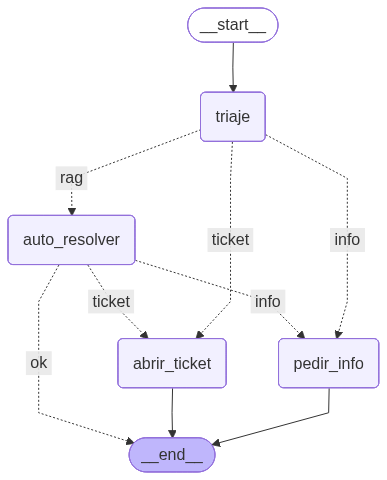

In [109]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [120]:
PREGUNTA = "¿Puedo reembolsar mi internet?"

try:
    # Now using the local llm configured in the previous step
    temp = grafo.invoke({"pregunta": PREGUNTA})

    print(f"PREGUNTA: {PREGUNTA}")
    triaje_data = temp.get('triaje', {})
    decision = triaje_data.get('decision', 'N/A')
    urgencia = triaje_data.get('urgencia', 'N/A')

    print(f"DECISION: {decision} | URGENCIA: {urgencia}")
    print(f"RESPUESTA: {temp.get('respuesta', 'Sin respuesta')}")

except Exception as e:
    print(f"Error durante la ejecución: {e}")

Ejecutando nodo triaje...
Ejecutando nodo 'auto_resolver'...
Error durante la ejecución: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 18.11910608s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests',

In [134]:
mensajes_de_prueba = [
	"¿Puedo obtener un reembolso por el internet de mi home office?",
	"Quiero una excepción para teletrabajar durante 5 días.",
	"¿Cómo funciona la política de comidas para viajes?",
	"¿Existe una política para anticipos de vacaciones?",
	"¿Quién fue Napoleón Bonaparte?"
]

In [135]:
for prueba in mensajes_de_prueba:
  respuesta = grafo.invoke({"pregunta": prueba})
  print("")
  print(f"PREGUNTA: {prueba}")
  print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
  print(f"RESPUESTA: {respuesta['respuesta']}")
  if respuesta['citaciones']:
    for i, citacion in enumerate(respuesta['citaciones']):
      print(f"    - CITACIÓN {i + 1}:")
      print(f"      Camino del documento: {citacion.metadata['file_path']}")
      print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
  print("-----------------------------------------------")

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Ejecutando nodo triaje...
Ejecutando nodo 'auto_resolver'...


KeyboardInterrupt: 